# Week 4 Lab: Associative Learning Models

This week formalizes how organisms learn predictive relationships between events.
The lab implements two associative-learning models as **recursive update rules**,
where the state at trial $t$ feeds into trial $t+1$:

- **Part 1 - Rescorla-Wagner.** Learning is driven by prediction error:
  $$\Delta V_i = \alpha_i\,\beta\,(\lambda - V_{total}), \qquad V_{total} = \sum_i V_i$$
  Use it to reproduce acquisition, blocking, overshadowing, overexpectation, and
  conditioned inhibition.
- **Part 2 - Mackintosh (1975).** Extends prediction-error learning with a dynamic
  *associability* (attention) term that itself updates across trials.

Code cells are left blank for you to fill in. Both models are pure simulations -
no data files are needed for Part 1.

## Setup

Import `numpy`, `pandas`, `matplotlib`, and `seaborn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Part 1: The Rescorla-Wagner Model

### Task 1: Implement the update rule and simulate acquisition

Write a function that takes a list of trials - each trial is the set of stimuli present plus the US asymptote `lambda` (1.0 when the US occurs, 0.0 when it does not) - and applies the Rescorla-Wagner rule $\Delta V_i = \alpha_i\,\beta\,(\lambda - V_{total})$, where $V_{total}$ sums associative strengths over the stimuli present on that trial. Use it to simulate simple acquisition of a single CS and plot $V$ across trials.

Final V_A = 0.992


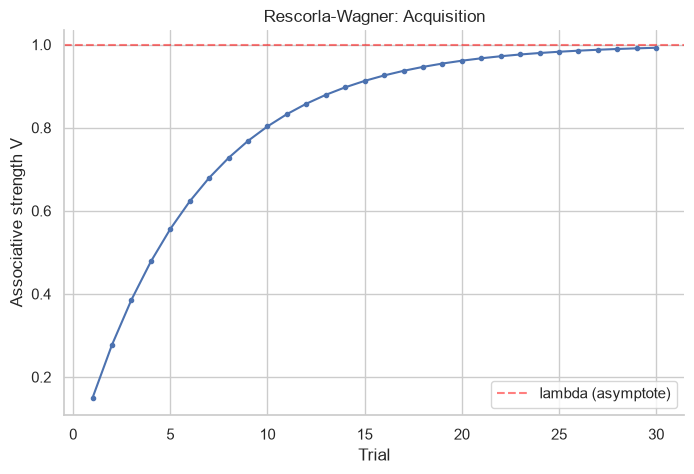

In [2]:
def rescorla_wagner(trials, alpha_A=0.5, alpha_B=0.5, beta=0.3):
    """Simulate the Rescorla-Wagner model for up to two stimuli, A and B.

    trials  : a list of trials. Each trial is written as (present, lam) where
              'present' is a list of the stimuli shown, like ['A'] or ['A', 'B'],
              and 'lam' (lambda) is 1.0 if the US happened or 0.0 if it did not.
    alpha_A : how noticeable stimulus A is (its salience), a number from 0 to 1
    alpha_B : how noticeable stimulus B is
    beta    : how quickly the US supports learning
    Returns a table (DataFrame) with the strengths V_A and V_B on every trial.
    """
    # Association strengths. Each starts at 0 (the animal has learned nothing yet).
    V_A = 0.0
    V_B = 0.0

    # We'll build three lists, one value per trial, then turn them into a table.
    trial_numbers = []
    V_A_history = []
    V_B_history = []

    trial_number = 0
    for trial in trials:
        trial_number = trial_number + 1
        present = trial[0]   # the stimuli shown this trial, e.g. ['A'] or ['A', 'B']
        lam = trial[1]       # 1.0 if the US occurred this trial, otherwise 0.0

        # V_total = how strongly the US is expected, adding up only the
        # stimuli that are actually present on this trial.
        V_total = 0.0
        if 'A' in present:
            V_total = V_total + V_A
        if 'B' in present:
            V_total = V_total + V_B

        # Prediction error: how surprising the US was, given what was expected.
        prediction_error = lam - V_total

        # Every stimulus that is present takes a step toward predicting the US.
        # The step size depends on that stimulus's salience (alpha) and beta.
        if 'A' in present:
            V_A = V_A + alpha_A * beta * prediction_error
        if 'B' in present:
            V_B = V_B + alpha_B * beta * prediction_error

        # Save this trial's numbers so we can plot them afterward.
        trial_numbers.append(trial_number)
        V_A_history.append(V_A)
        V_B_history.append(V_B)

    # Put the three lists together into a table with one row per trial.
    return pd.DataFrame({'trial': trial_numbers, 'V_A': V_A_history, 'V_B': V_B_history})

# Simple acquisition: one CS (A), US present every trial.
# [(['A'], 1.0)] * 30 means "a list holding 30 copies of the trial (['A'], 1.0)".
acq = rescorla_wagner([(['A'], 1.0)] * 30, alpha_A=0.5)
print("Final V_A =", round(acq['V_A'].iloc[-1], 3))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(acq['trial'], acq['V_A'], marker='o', ms=3)
ax.axhline(1.0, color='red', ls='--', alpha=0.5, label='lambda (asymptote)')
ax.set_xlabel('Trial'); ax.set_ylabel('Associative strength V'); ax.set_title('Rescorla-Wagner: Acquisition')
ax.legend(); sns.despine(); plt.show()

### Task 2: Reproduce blocking, overshadowing, overexpectation, and conditioned inhibition

Each phenomenon falls out of the shared prediction-error term $(\lambda - V_{total})$. Build the trial schedules and confirm the signatures:

- **Blocking:** train A->US alone, then AB->US. B barely learns ($V_B \approx 0$).
- **Overshadowing:** train AB->US with $\alpha_A > \alpha_B$. A captures more of $\lambda$.
- **Overexpectation:** train A->US and B->US separately to asymptote, then AB->US together. Both $V$ values *decrease* because $V_{total} \approx 2\lambda$ overpredicts.
- **Conditioned inhibition:** interleave A->US with AB->no US. B acquires *negative* strength.

Blocking      : V_B final  = 0.019 (blocked -> near 0)
Overshadowing : V_A= 0.75  V_B= 0.25
Overexpect.   : V_A pre-compound = 0.961  -> final = 0.5
Cond. inhib.  : V_B final  = -0.911 (negative)


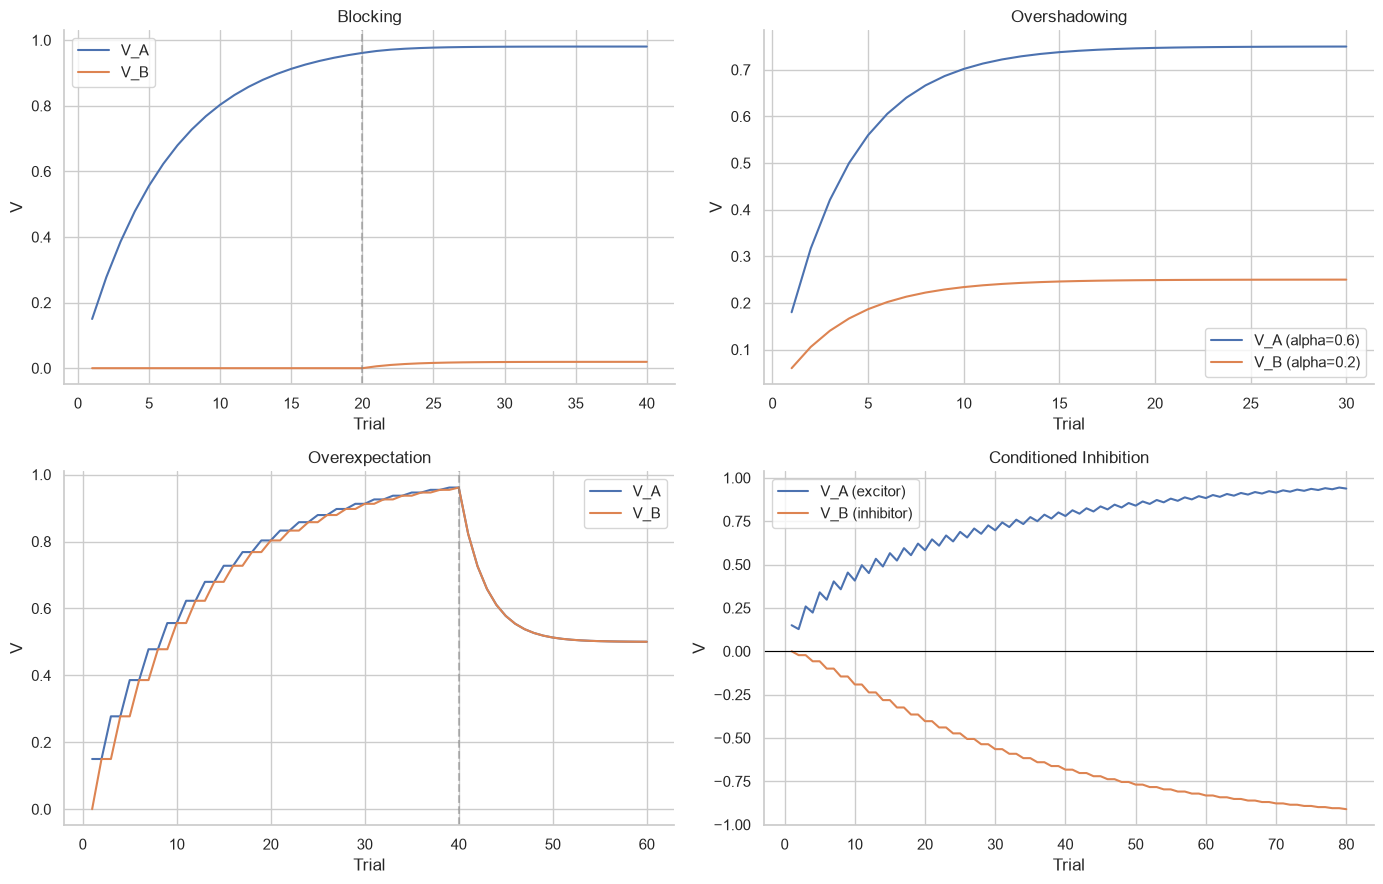

In [3]:
# Blocking: A -> US (x20), then AB -> US (x20)
blocking = rescorla_wagner([(['A'], 1.0)] * 20 + [(['A', 'B'], 1.0)] * 20, alpha_A=0.5, alpha_B=0.5)

# Overshadowing: AB -> US with CS1 more salient than CS2
overshadow = rescorla_wagner([(['A', 'B'], 1.0)] * 30, alpha_A=0.6, alpha_B=0.2)

# Overexpectation: A->US and B->US separately (x20 each, interleaved), then AB->US together (x20)
overexp = rescorla_wagner([(['A'], 1.0), (['B'], 1.0)] * 20 + [(['A', 'B'], 1.0)] * 20,
                          alpha_A=0.5, alpha_B=0.5)

# Conditioned inhibition: A->US interleaved with AB->no US
condinhib = rescorla_wagner([(['A'], 1.0), (['A', 'B'], 0.0)] * 40, alpha_A=0.5, alpha_B=0.5)

print("Blocking      : V_B final  =", round(blocking['V_B'].iloc[-1], 3), "(blocked -> near 0)")
print("Overshadowing : V_A=", round(overshadow['V_A'].iloc[-1], 3),
      " V_B=", round(overshadow['V_B'].iloc[-1], 3))
print("Overexpect.   : V_A pre-compound =", round(overexp['V_A'].iloc[39], 3),
      " -> final =", round(overexp['V_A'].iloc[-1], 3))
print("Cond. inhib.  : V_B final  =", round(condinhib['V_B'].iloc[-1], 3), "(negative)")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].plot(blocking['trial'], blocking['V_A'], label='V_A'); axes[0,0].plot(blocking['trial'], blocking['V_B'], label='V_B')
axes[0,0].axvline(20, color='gray', ls='--', alpha=0.5); axes[0,0].set_title('Blocking'); axes[0,0].legend()
axes[0,1].plot(overshadow['trial'], overshadow['V_A'], label='V_A (alpha=0.6)'); axes[0,1].plot(overshadow['trial'], overshadow['V_B'], label='V_B (alpha=0.2)')
axes[0,1].set_title('Overshadowing'); axes[0,1].legend()
axes[1,0].plot(overexp['trial'], overexp['V_A'], label='V_A'); axes[1,0].plot(overexp['trial'], overexp['V_B'], label='V_B')
axes[1,0].axvline(40, color='gray', ls='--', alpha=0.5); axes[1,0].set_title('Overexpectation'); axes[1,0].legend()
axes[1,1].plot(condinhib['trial'], condinhib['V_A'], label='V_A (excitor)'); axes[1,1].plot(condinhib['trial'], condinhib['V_B'], label='V_B (inhibitor)')
axes[1,1].axhline(0, color='black', lw=0.8); axes[1,1].set_title('Conditioned Inhibition'); axes[1,1].legend()
for ax in axes.flat: ax.set_xlabel('Trial'); ax.set_ylabel('V')
plt.tight_layout(); sns.despine(); plt.show()

## Part 2: The Mackintosh Model (Recursive Associability)

### Task 3: Implement the model

The Mackintosh (1975) model adds a dynamic *associability* term: a stimulus that predicts the US better than its competitors gains attention (its $\alpha$ rises), while a poorer predictor loses it. Implement the update rules for association strength $V$ and associability $\alpha$, then write simulation functions for (a) basic conditioning, (b) overshadowing (two CSs with different initial associability), and (c) blocking (CS1 trained alone, then CS1+CS2).

In [4]:
# --- The Mackintosh (1975) model, built from two small, well-documented rules ---
#
# Rather than wrapping everything in a class, we write a few simple functions.
# Each function does ONE clear job: it takes some numbers in and returns a number.
# The simulation functions then call these helpers inside a loop, one trial at a time.
#
# Two quantities change across trials:
#   V     = association strength (how strongly a CS predicts the US)
#   alpha = associability        (how much "attention" a CS gets)
#
# IMPORTANT (this is what makes Mackintosh different from Rescorla-Wagner, and it
# matches the Week 4 chapter): each CS learns from its OWN prediction error
# (lambda - V_CS), NOT from the summed compound (lambda - sum of all V). The
# competition between stimuli happens through the attention rule below, not
# through a shared error term.
#
# pandas (pd) was already imported in the Setup cell, so we can use it here.


def delta_V(alpha, V_self, lambda_val, theta):
    """Return how much one CS's association strength changes on a single trial.

    Chapter rule:  delta V_CS = alpha_CS * beta * (lambda - V_CS)
    Here 'theta' plays the role of the US learning rate 'beta' from the chapter.

    The piece (lambda - V_self) is this CS's OWN "surprise": how far the actual
    US (lambda) is from what THIS stimulus alone currently predicts (V_self).
    A bigger surprise produces a bigger change; alpha and theta scale it.
    """
    own_surprise = lambda_val - V_self
    return alpha * theta * own_surprise


def updated_alpha(alpha, V_self, V_other, lambda_val, theta):
    """Return the new associability (attention) for one CS.

    Chapter rule: a CS that predicts the US BETTER than its competitor earns
    more attention; a worse predictor loses attention. "Better predictor" means
    a SMALLER error (its V is closer to lambda).

      - error_self  = how wrong THIS CS's prediction is   = |lambda - V_self|
      - error_other = how wrong the OTHER CS's prediction is = |lambda - V_other|

    If this CS is the better predictor (error_self < error_other), then
    (error_other - error_self) is positive, so we ADD a positive amount and
    alpha goes UP. If it is the worse predictor, alpha goes DOWN. That is exactly
    the direction the chapter describes.

    (For a single CS with no competitor we pass V_other = 0, i.e. "nothing else
    predicts the US," so a CS that comes to predict the US gains attention.)
    """
    error_self = abs(lambda_val - V_self)
    error_other = abs(lambda_val - V_other)
    return alpha + theta * (error_other - error_self)


def clamp(value, low=0.01, high=1.0):
    """Keep a number from drifting outside a sensible range.

    Associability should stay between 'low' and 'high'. min/max do the work:
      - min(high, value) makes sure we never go above 'high'
      - max(low, ...)     makes sure we never go below 'low'
    """
    return max(low, min(high, value))


def simulate_basic_conditioning(trials=25, alpha_init=0.5, theta=0.3, lambda_val=1.0):
    """Simplest case: ONE CS paired with the US on every trial.

    We start with no learning (V = 0) and watch V climb toward lambda while the
    CS, now a reliable predictor, gradually gains attention (alpha rises).
    """
    alpha = alpha_init   # current attention to the CS
    V = 0.0              # current association strength (starts at zero)

    # Build one list per quantity, adding a value each trial.
    trial_numbers = []
    V_history = []
    alpha_history = []

    for trial_number in range(1, trials + 1):
        # Move V a step toward lambda. With one CS, "V_self" is just V.
        change = delta_V(alpha, V, lambda_val, theta)
        V = V + change

        # Update attention. There is no competing CS, so the "other"
        # prediction is 0.0 (nothing else predicts the US).
        alpha = updated_alpha(alpha, V, 0.0, lambda_val, theta)
        alpha = clamp(alpha)

        trial_numbers.append(trial_number)
        V_history.append(V)
        alpha_history.append(alpha)

    return pd.DataFrame({'trial': trial_numbers, 'V': V_history, 'alpha': alpha_history})


def simulate_overshadowing(trials=30, alpha1_init=0.8, alpha2_init=0.3, theta=0.3, lambda_val=1.0):
    """Two CSs presented TOGETHER. The more salient CS overshadows the other.

    CS1 starts with more attention, so it learns faster, becomes the better
    predictor, and the attention rule then pushes alpha1 up and alpha2 down --
    so CS2 falls further behind. That widening gap is overshadowing.
    """
    alpha1 = alpha1_init   # attention to CS1
    alpha2 = alpha2_init   # attention to CS2
    V1 = 0.0               # association strength of CS1
    V2 = 0.0               # association strength of CS2

    trial_numbers = []
    V1_history = []
    V2_history = []
    alpha1_history = []
    alpha2_history = []

    for trial_number in range(1, trials + 1):
        # Each CS changes based on ITS OWN prediction error (not the sum).
        change1 = delta_V(alpha1, V1, lambda_val, theta)
        change2 = delta_V(alpha2, V2, lambda_val, theta)
        V1 = V1 + change1
        V2 = V2 + change2

        # Update each CS's attention by comparing it against the OTHER CS.
        alpha1 = clamp(updated_alpha(alpha1, V1, V2, lambda_val, theta))
        alpha2 = clamp(updated_alpha(alpha2, V2, V1, lambda_val, theta))

        trial_numbers.append(trial_number)
        V1_history.append(V1)
        V2_history.append(V2)
        alpha1_history.append(alpha1)
        alpha2_history.append(alpha2)

    return pd.DataFrame({'trial': trial_numbers,
                         'V1': V1_history, 'V2': V2_history,
                         'alpha1': alpha1_history, 'alpha2': alpha2_history})


def simulate_blocking(trials=40, alpha_init=0.5, theta=0.3, lambda_val=1.0):
    """Blocking happens in TWO phases:

      Phase 1 (trials 1-20):  CS1 alone -> US.   CS1 learns to predict the US.
      Phase 2 (trials 21-40): CS1 + CS2 -> US.

    In Mackintosh's model the blocking is driven by ATTENTION. Entering Phase 2,
    CS1 already predicts the US well (small error) while new CS2 does not (large
    error). The attention rule drives alpha2 down quickly, so CS2 barely learns.
    """
    alpha1 = alpha_init
    alpha2 = alpha_init
    V1 = 0.0
    V2 = 0.0

    trial_numbers = []
    V1_history = []
    V2_history = []
    alpha1_history = []
    alpha2_history = []

    for trial_number in range(1, trials + 1):
        if trial_number <= 20:
            # Phase 1: only CS1 is present, so only CS1 changes.
            change1 = delta_V(alpha1, V1, lambda_val, theta)
            V1 = V1 + change1
            alpha1 = clamp(updated_alpha(alpha1, V1, 0.0, lambda_val, theta))
        else:
            # Phase 2: CS1 and CS2 together; each still uses its OWN error.
            change1 = delta_V(alpha1, V1, lambda_val, theta)
            change2 = delta_V(alpha2, V2, lambda_val, theta)
            V1 = V1 + change1
            V2 = V2 + change2
            alpha1 = clamp(updated_alpha(alpha1, V1, V2, lambda_val, theta))
            alpha2 = clamp(updated_alpha(alpha2, V2, V1, lambda_val, theta))

        trial_numbers.append(trial_number)
        V1_history.append(V1)
        V2_history.append(V2)
        alpha1_history.append(alpha1)
        alpha2_history.append(alpha2)

    return pd.DataFrame({'trial': trial_numbers,
                         'V1': V1_history, 'V2': V2_history,
                         'alpha1': alpha1_history, 'alpha2': alpha2_history})

### Task 4: Run the simulations and visualize

Run each simulation across a range of learning rates (theta), combine the results, and plot association strength and associability over trials. Confirm the expected signatures: overshadowing (CS1 gains more $V$ than CS2) and blocking (CS2 shows minimal learning in Phase 2).

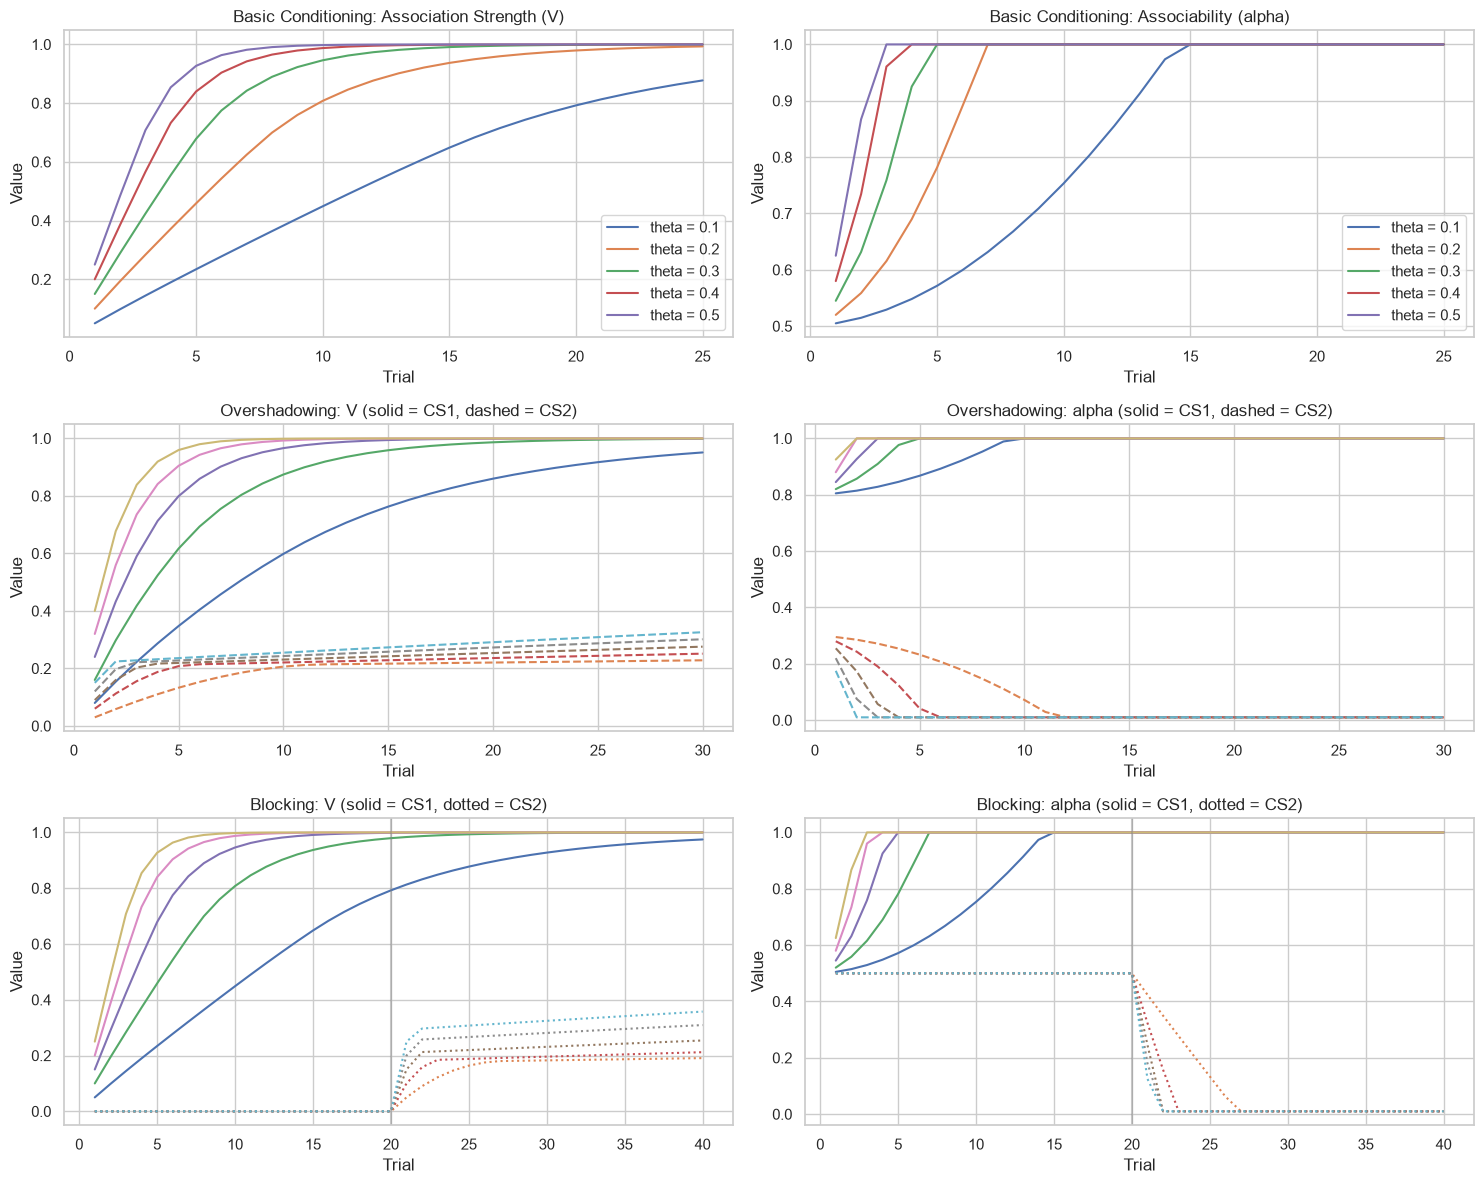

Overshadowing - final association strengths:
  theta = 0.1 : V1 = 0.951  V2 = 0.228
  theta = 0.2 : V1 = 0.999  V2 = 0.251
  theta = 0.3 : V1 = 1.0  V2 = 0.276
  theta = 0.4 : V1 = 1.0  V2 = 0.301
  theta = 0.5 : V1 = 1.0  V2 = 0.326

Blocking - final CS2 strength (should stay low):
  theta = 0.1 : V2 = 0.191
  theta = 0.2 : V2 = 0.212
  theta = 0.3 : V2 = 0.254
  theta = 0.4 : V2 = 0.309
  theta = 0.5 : V2 = 0.358


In [5]:
# Run each simulation across a range of learning rates (theta) and plot the
# results. A bigger theta means faster learning.
# (The shared mackintosh_model_data.csv is generated by the instructor
#  data-creation notebook; here we just simulate and plot.)
learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

# A 3-row, 2-column grid of plots: one row per phenomenon, V on the left and
# associability (alpha) on the right.
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Row 1: basic conditioning. One line per learning rate.
for theta in learning_rates:
    result = simulate_basic_conditioning(theta=theta)
    label = "theta = " + str(theta)
    axes[0, 0].plot(result['trial'], result['V'], label=label)
    axes[0, 1].plot(result['trial'], result['alpha'], label=label)

# Row 2: overshadowing. CS1 (solid) starts more salient than CS2 (dashed).
for theta in learning_rates:
    result = simulate_overshadowing(theta=theta)
    axes[1, 0].plot(result['trial'], result['V1'], linestyle='-')
    axes[1, 0].plot(result['trial'], result['V2'], linestyle='--')
    axes[1, 1].plot(result['trial'], result['alpha1'], linestyle='-')
    axes[1, 1].plot(result['trial'], result['alpha2'], linestyle='--')

# Row 3: blocking. CS1 (solid) is trained first; CS2 (dotted) is added at trial 21.
for theta in learning_rates:
    result = simulate_blocking(theta=theta)
    axes[2, 0].plot(result['trial'], result['V1'], linestyle='-')
    axes[2, 0].plot(result['trial'], result['V2'], linestyle=':')
    axes[2, 1].plot(result['trial'], result['alpha1'], linestyle='-')
    axes[2, 1].plot(result['trial'], result['alpha2'], linestyle=':')
axes[2, 0].axvline(20, color='gray', alpha=0.4)   # Phase 2 starts here
axes[2, 1].axvline(20, color='gray', alpha=0.4)

# Titles, axis labels, and legends.
axes[0, 0].set_title('Basic Conditioning: Association Strength (V)')
axes[0, 1].set_title('Basic Conditioning: Associability (alpha)')
axes[1, 0].set_title('Overshadowing: V (solid = CS1, dashed = CS2)')
axes[1, 1].set_title('Overshadowing: alpha (solid = CS1, dashed = CS2)')
axes[2, 0].set_title('Blocking: V (solid = CS1, dotted = CS2)')
axes[2, 1].set_title('Blocking: alpha (solid = CS1, dotted = CS2)')
for ax in axes.flat:
    ax.set_xlabel('Trial')
    ax.set_ylabel('Value')
axes[0, 0].legend()
axes[0, 1].legend()

plt.tight_layout()
plt.show()

# Print the final numbers so we can check the expected signatures.
# Overshadowing: CS1 should end up much stronger than CS2.
print("Overshadowing - final association strengths:")
for theta in learning_rates:
    result = simulate_overshadowing(theta=theta)
    V1_final = round(result['V1'].iloc[-1], 3)
    V2_final = round(result['V2'].iloc[-1], 3)
    print("  theta =", theta, ": V1 =", V1_final, " V2 =", V2_final)

# Blocking: CS2 should stay low because CS1 already predicts the US.
print()
print("Blocking - final CS2 strength (should stay low):")
for theta in learning_rates:
    result = simulate_blocking(theta=theta)
    V2_final = round(result['V2'].iloc[-1], 3)
    print("  theta =", theta, ": V2 =", V2_final)

## Wrap-up

Compare the two models. The Rescorla-Wagner model explains blocking, overshadowing, overexpectation, and conditioned inhibition entirely through a shared prediction-error term with *fixed* saliences. What does the Mackintosh model add by letting associability change across trials, and which phenomena motivate that addition? Where in each update rule does the recursive structure $X(t+1) = f(X(t), I(t))$ appear?